# Combined mmFall + TI IWR6843 Datasets — Harmonization & Tensor Pipeline

This notebook manages the unified, multi-sensor benchmark combining **mmFall** (77 GHz, 1,182 clips) and **TI IWR6843** (60–64 GHz, 728 clips) into **1,910 balanced motion clips** (955 Fall : 955 ADL).

### Key Harmonization Principles

1. **Decoupled Micro-Doppler Spectrogram (Representation 1)**:
   - Computed directly from **raw, variable-length point clouds** prior to any padding or resampling.
   - Bins only measured Doppler velocities into the $64 \times 64$ time-frequency grid across 3 channels:
     - **Channel 0**: Velocity density histogram.
     - **Channel 1**: Kinetic energy histogram ($v^2$-weighted).
     - **Channel 2**: Temporal velocity gradient ($\Delta v / \Delta t$).
   - Completely free of synthetic centroid duplicates, zero-padding, or artificial energy bins.

2. **Uniform Random Resampling ($N=32$ Points/Frame)**:
   - Deprecates Algorithm 1 centroid duplication and outward scaling.
   - Preserves exact raw kinematic coordinates $[\Delta X, \Delta Y, Z, v_{\text{doppler}}]$ without distortion.
   - When $M < 32$, samples uniformly with replacement from real points.
   - When $M \ge 32$, samples 32 points uniformly without replacement.

3. **Standardized Downstream Dimensions**:
   - **Base Tensor `X_combined_clean_balanced.npy`**: `(1910, 10, 32, 4)`.
   - **Representation 1 (Spectrogram)**: `(1910, 3, 64, 64)`.
   - **Representation 2 (Projections)**: `(1910, 3, 64, 64)`.
   - **Representation 3 (PointNet 3D Point Set)**: `(1910, 5, 320)` ($10\text{ frames} \times 32\text{ points}$).
   - **Labels**: Exactly 1:1 balanced (`955 Fall : 955 ADL`) with deterministic permutation (`seed=42`).

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../../datasets/preprocessed")

# Load unified harmonized tensors
X_combined = np.load(preproc_dir / "X_combined_clean_balanced.npy")
y_combined = np.load(preproc_dir / "y_combined_clean_balanced.npy")

X_rep1 = np.load(preproc_dir / "X_rep1_spectrogram_combined.npy")
X_rep2 = np.load(preproc_dir / "X_rep2_projections_combined.npy")
X_rep3 = np.load(preproc_dir / "X_rep3_pointset_combined.npy")

print("=== Unified Combined Multi-Sensor Benchmark Summary ===")
print(f"Base 4D CNN Tensor:         {X_combined.shape} (Clips x Frames x Points x Channels)")
print(f"Representation 1 (Spectro):  {X_rep1.shape} (Clips x Channels x Freq x Time)")
print(f"Representation 2 (Project):  {X_rep2.shape} (Clips x Channels x Height x Width)")
print(f"Representation 3 (PointNet): {X_rep3.shape} (Clips x Channels x Points)")
print(f"Ground Truth Class Balance: {np.bincount(y_combined.astype(int))} (0 = ADL, 1 = Fall)")

=== Unified Combined Multi-Sensor Benchmark Summary ===
Base 4D CNN Tensor:         (1910, 10, 32, 4) (Clips x Frames x Points x Channels)
Representation 1 (Spectro):  (1910, 3, 64, 64) (Clips x Channels x Freq x Time)
Representation 2 (Project):  (1910, 3, 64, 64) (Clips x Channels x Height x Width)
Representation 3 (PointNet): (1910, 5, 320) (Clips x Channels x Points)
Ground Truth Class Balance: [955 955] (0 = ADL, 1 = Fall)


## 1. Cross-Sensor Point Cloud Verification (N=32 Uniform Resampling)

Below we visualize a standardized $N=32$ point cloud frame from **mmFall (77 GHz)** next to a frame from **TI IWR6843 (60 GHz)**.
Both sensors now share the uniform $N=32$ point format with intact, undistorted measured kinematics $[\Delta x, \Delta y, z, v]$. 

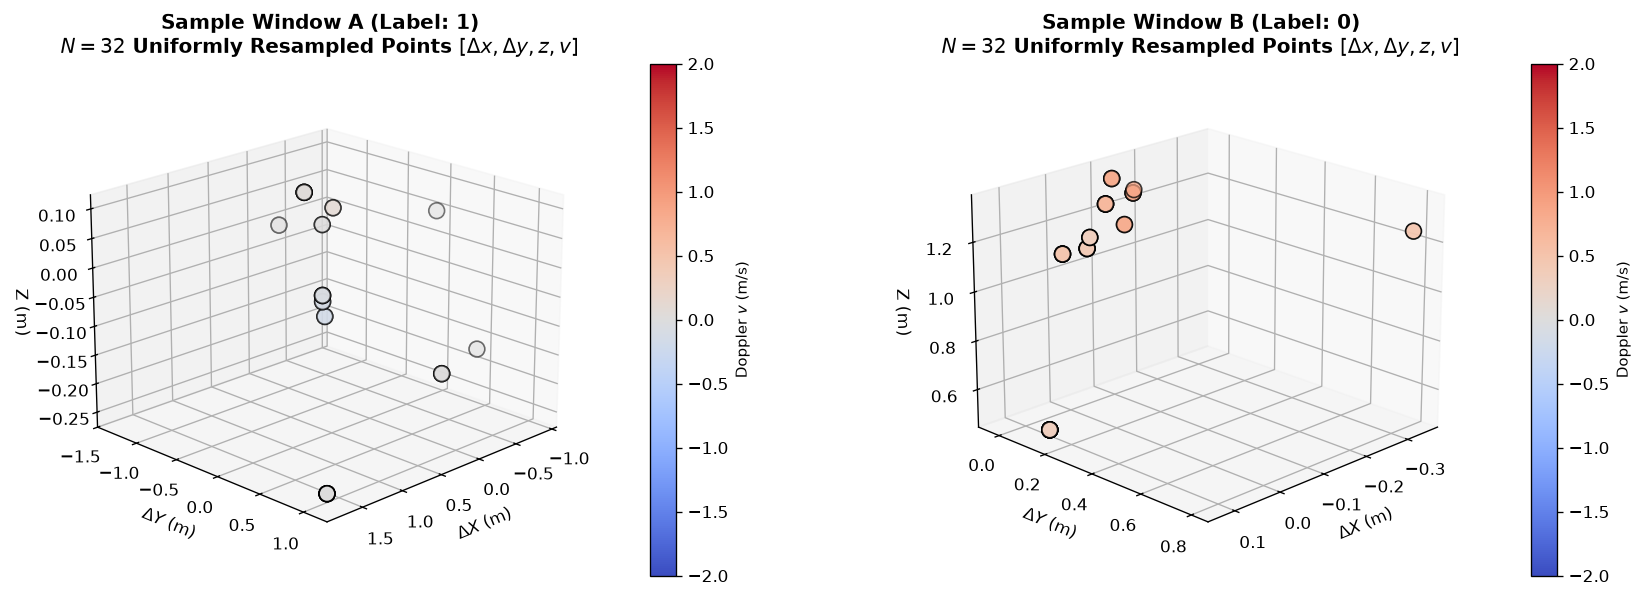

In [2]:
import matplotlib.pyplot as plt

# Take sample frames from the combined array
# (Clip 0 and Clip 1 represent shuffled clips from both sensors)
frame_a = X_combined[0, 5] # Clip 0, Frame 5
frame_b = X_combined[1, 5] # Clip 1, Frame 5

fig = plt.figure(figsize=(16, 5), dpi=120)

# Subplot 1
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(frame_a[:, 0], frame_a[:, 1], frame_a[:, 2], 
                  c=frame_a[:, 3], cmap='coolwarm', s=90, edgecolors='black', vmin=-2, vmax=2)
ax1.set_title(f'Sample Window A (Label: {y_combined[0]})\n$N = {len(frame_a)}$ Uniformly Resampled Points $[\\Delta x, \\Delta y, z, v]$', fontsize=12, fontweight='bold')
ax1.set_xlabel('$\\Delta X$ (m)'); ax1.set_ylabel('$\\Delta Y$ (m)'); ax1.set_zlabel('Z (m)')
cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.03, pad=0.08)
cbar1.set_label('Doppler $v$ (m/s)', fontsize=9)
ax1.view_init(elev=20, azim=45)

# Subplot 2
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(frame_b[:, 0], frame_b[:, 1], frame_b[:, 2], 
                  c=frame_b[:, 3], cmap='coolwarm', s=90, edgecolors='black', vmin=-2, vmax=2)
ax2.set_title(f'Sample Window B (Label: {y_combined[1]})\n$N = {len(frame_b)}$ Uniformly Resampled Points $[\\Delta x, \\Delta y, z, v]$', fontsize=12, fontweight='bold')
ax2.set_xlabel('$\\Delta X$ (m)'); ax2.set_ylabel('$\\Delta Y$ (m)'); ax2.set_zlabel('Z (m)')
cbar2 = fig.colorbar(sc2, ax=ax2, fraction=0.03, pad=0.08)
cbar2.set_label('Doppler $v$ (m/s)', fontsize=9)
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

## 2. Decoupled Representation 1 Verification (Micro-Doppler Spectrogram)

The Micro-Doppler Spectrogram is generated directly from raw point clouds prior to resampling.
Below, we visualize the three channels for a sample Fall event:
* **Channel 0**: Velocity Density
* **Channel 1**: Kinetic Energy ($v^2$-weighted)
* **Channel 2**: Velocity Gradient ($\Delta v / \Delta t$)

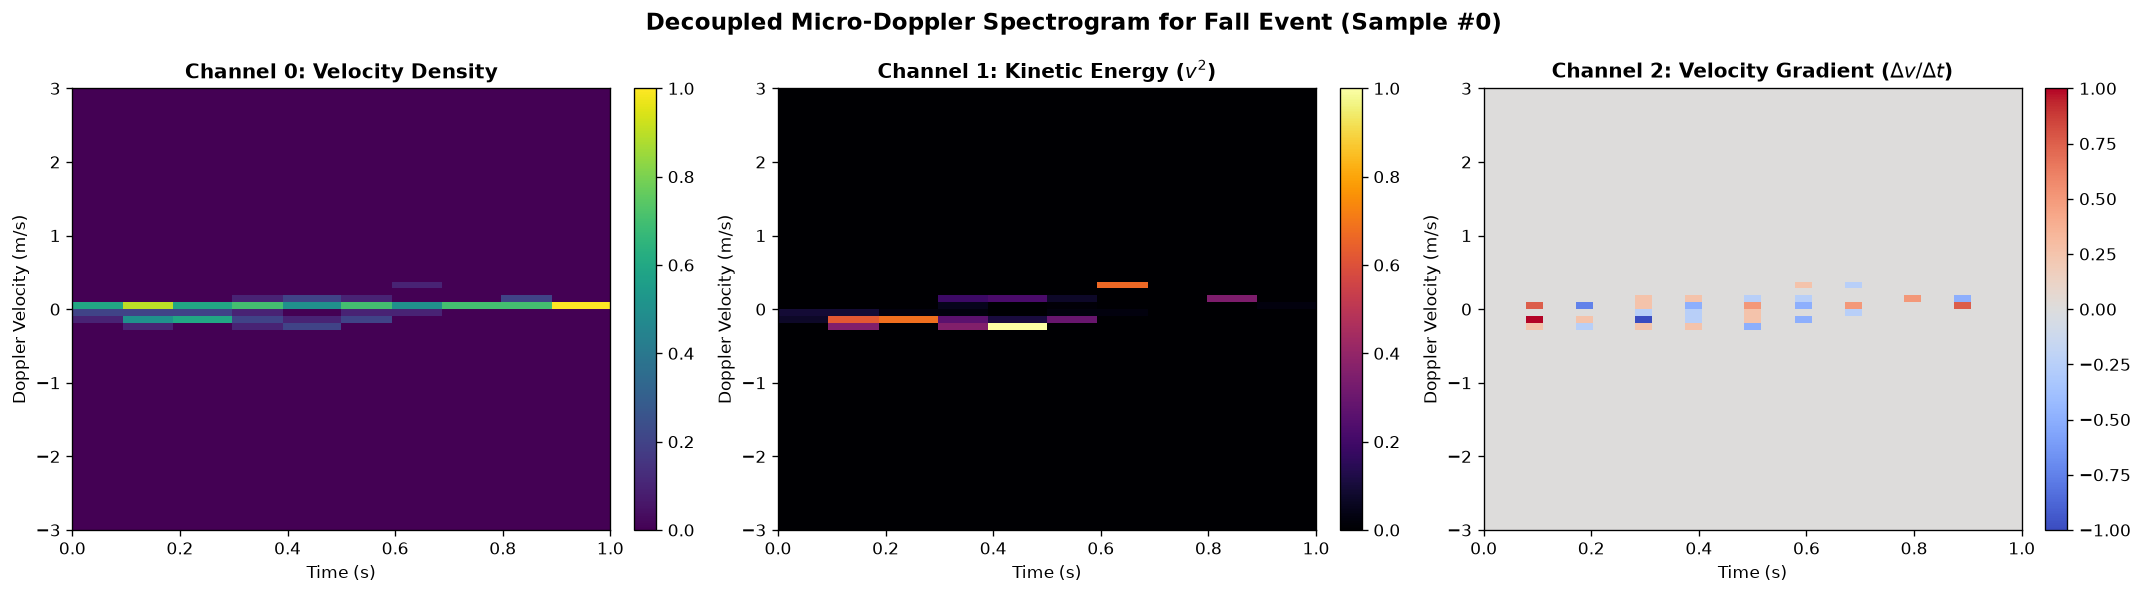

In [3]:
# Find a fall event index
fall_idx = np.where(y_combined == 1)[0][0]
spec_sample = X_rep1[fall_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
titles = ["Channel 0: Velocity Density", "Channel 1: Kinetic Energy ($v^2$)", "Channel 2: Velocity Gradient ($\\Delta v / \\Delta t$)"]
cmaps = ["viridis", "inferno", "coolwarm"]

for c in range(3):
    im = axes[c].imshow(spec_sample[c], cmap=cmaps[c], aspect='auto', origin='lower', extent=[0, 1.0, -3.0, 3.0])
    axes[c].set_title(titles[c], fontsize=12, fontweight='bold')
    axes[c].set_xlabel('Time (s)', fontsize=10)
    axes[c].set_ylabel('Doppler Velocity (m/s)', fontsize=10)
    fig.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

plt.suptitle(f'Decoupled Micro-Doppler Spectrogram for Fall Event (Sample #{fall_idx})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()